# 🏠 Anomaly Detection in Elderly Daily Activities
## LSTM Autoencoder — Mode non supervisé pur
### ☁️ Google Colab

| | |
|---|---|
| **Input** | CSV brut : Time, Unix, Aggregate, Appliance1–9, Issues |
| **On utilise** | `Aggregate` uniquement |
| **On ignore** | Appliance1–9, Issues (flag technique capteur, pas un label santé) |
| **Conversion** | 15 sec → 1 min (moyenne) → pivot jour → **(n_jours × 1440)** |
| **Stratégie** | Train sur 4 maisons → Test sur 1 maison |
| **Mode** | Non supervisé pur — le modèle détecte seul les jours inhabituels |

---
### ⚡ Avant de lancer : Runtime → Change runtime type → **T4 GPU**

## 0. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : Tesla T4


## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

Device : cuda


## 2. Configuration
> ✏️ **Seule cette cellule est à modifier.**

In [3]:
# ── Chemins ────────────────────────────────────────────────────────────────────
DRIVE_BASE = '/content/drive/MyDrive/REFIT_dataset clean'

HOUSE_FILES = [
    'CLEAN_House1.csv',
    'CLEAN_House2.csv',
    'CLEAN_House3.csv',
    'CLEAN_House4.csv',
    'CLEAN_House5.csv',
]

TEST_HOUSE_IDX = 4          # 0-based : House 5 comme test
OUTPUT_DIR     = f'{DRIVE_BASE}/outputs'
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# ── Hyperparamètres ────────────────────────────────────────────────────────────
CFG = dict(
    house_paths          = [f'{DRIVE_BASE}/{f}' for f in HOUSE_FILES],
    test_house_idx       = TEST_HOUSE_IDX,
    output_dir           = OUTPUT_DIR,

    # Colonne utilisée
    time_col             = 'Time',
    aggregate_col        = 'Aggregate',

    # Conversion journalière
    minutes_per_day      = 1440,
    min_day_coverage     = 1152,   # garder les jours avec >= 80% de minutes réelles
    max_gap_fill_minutes = 30,     # forward-fill jusqu'à 30 min de gaps capteur

    # Modèle
    hidden_size          = 128,
    num_layers           = 2,
    dropout              = 0.2,

    # Entraînement
    epochs               = 50,
    batch_size           = 32,
    lr                   = 1e-3,
    val_split            = 0.1,

    # Seuil anomalie
    threshold_percentile = 95,
)

print(f'Maisons         : {HOUSE_FILES}')
print(f'Maison de test  : House {TEST_HOUSE_IDX + 1}')
print(f'Output dir      : {OUTPUT_DIR}')
print(f'Device          : {DEVICE}')

Maisons         : ['CLEAN_House1.csv', 'CLEAN_House2.csv', 'CLEAN_House3.csv', 'CLEAN_House4.csv', 'CLEAN_House5.csv']
Maison de test  : House 5
Output dir      : /content/drive/MyDrive/REFIT_dataset clean/outputs
Device          : cuda


## 3. Chargement & Conversion → format journalier (n_jours × 1440)

In [4]:
def save_fig(name):
    path = f"{CFG['output_dir']}/{name}"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'  Sauvegarde -> {path}')


def load_house(path, cfg):
    """
    Charge un CSV brut REFIT et retourne une matrice (n_jours, 1440).

    Etapes :
      1. Lire uniquement Time + Aggregate (toutes les autres colonnes ignorees)
      2. Reechantillonner 15 sec -> 1 min (moyenne)
      3. Grouper par jour
         - Ignorer si < min_day_coverage minutes reelles
         - Forward-fill les gaps jusqu'a max_gap_fill_minutes
         - Zero-fill le reste
      4. Retourner matrice (n_jours, 1440) + liste de dates
    """
    # 1. Lecture — on ignore volontairement Appliance1-9 et Issues
    df = pd.read_csv(path, usecols=[cfg['time_col'], cfg['aggregate_col']])
    df[cfg['time_col']] = pd.to_datetime(df[cfg['time_col']])
    df = df.set_index(cfg['time_col']).sort_index()

    # 2. Reechantillonnage -> 1 minute
    minute_series = df[cfg['aggregate_col']].resample('1min').mean()

    # 3. Pivot journalier
    X_days, dates, skipped = [], [], 0
    for date, grp in minute_series.groupby(minute_series.index.date):
        n_real = grp.notna().sum()
        if n_real < cfg['min_day_coverage']:
            skipped += 1
            continue

        full_idx = pd.date_range(
            start=f'{date} 00:00',
            periods=cfg['minutes_per_day'],
            freq='1min'
        )
        day = grp.reindex(full_idx)
        day = day.ffill(limit=cfg['max_gap_fill_minutes'])
        day = day.fillna(0)

        X_days.append(day.values.astype(np.float32))
        dates.append(str(date))

    X = np.array(X_days, dtype=np.float32)
    return X, dates, skipped


# Chargement des 5 maisons
houses = {}
for i, path in enumerate(CFG['house_paths']):
    tag = 'TEST' if i == CFG['test_house_idx'] else 'TRAIN'
    print(f'Chargement House {i+1} [{tag}] ...')
    X, dates, skipped = load_house(path, CFG)
    houses[i] = {'X': X, 'dates': dates}
    print(f'  {len(dates)} jours gardes | {skipped} ignores (<80% donnees) | Shape: {X.shape}')

Chargement House 1 [TRAIN] ...
  552 jours gardes | 88 ignores (<80% donnees) | Shape: (552, 1440)
Chargement House 2 [TRAIN] ...
  458 jours gardes | 161 ignores (<80% donnees) | Shape: (458, 1440)
Chargement House 3 [TRAIN] ...
  536 jours gardes | 80 ignores (<80% donnees) | Shape: (536, 1440)
Chargement House 4 [TRAIN] ...
  533 jours gardes | 102 ignores (<80% donnees) | Shape: (533, 1440)
Chargement House 5 [TEST] ...
  576 jours gardes | 73 ignores (<80% donnees) | Shape: (576, 1440)


## 4. Exploration des données

  Sauvegarde -> /content/drive/MyDrive/REFIT_dataset clean/outputs/01_load_curves.png


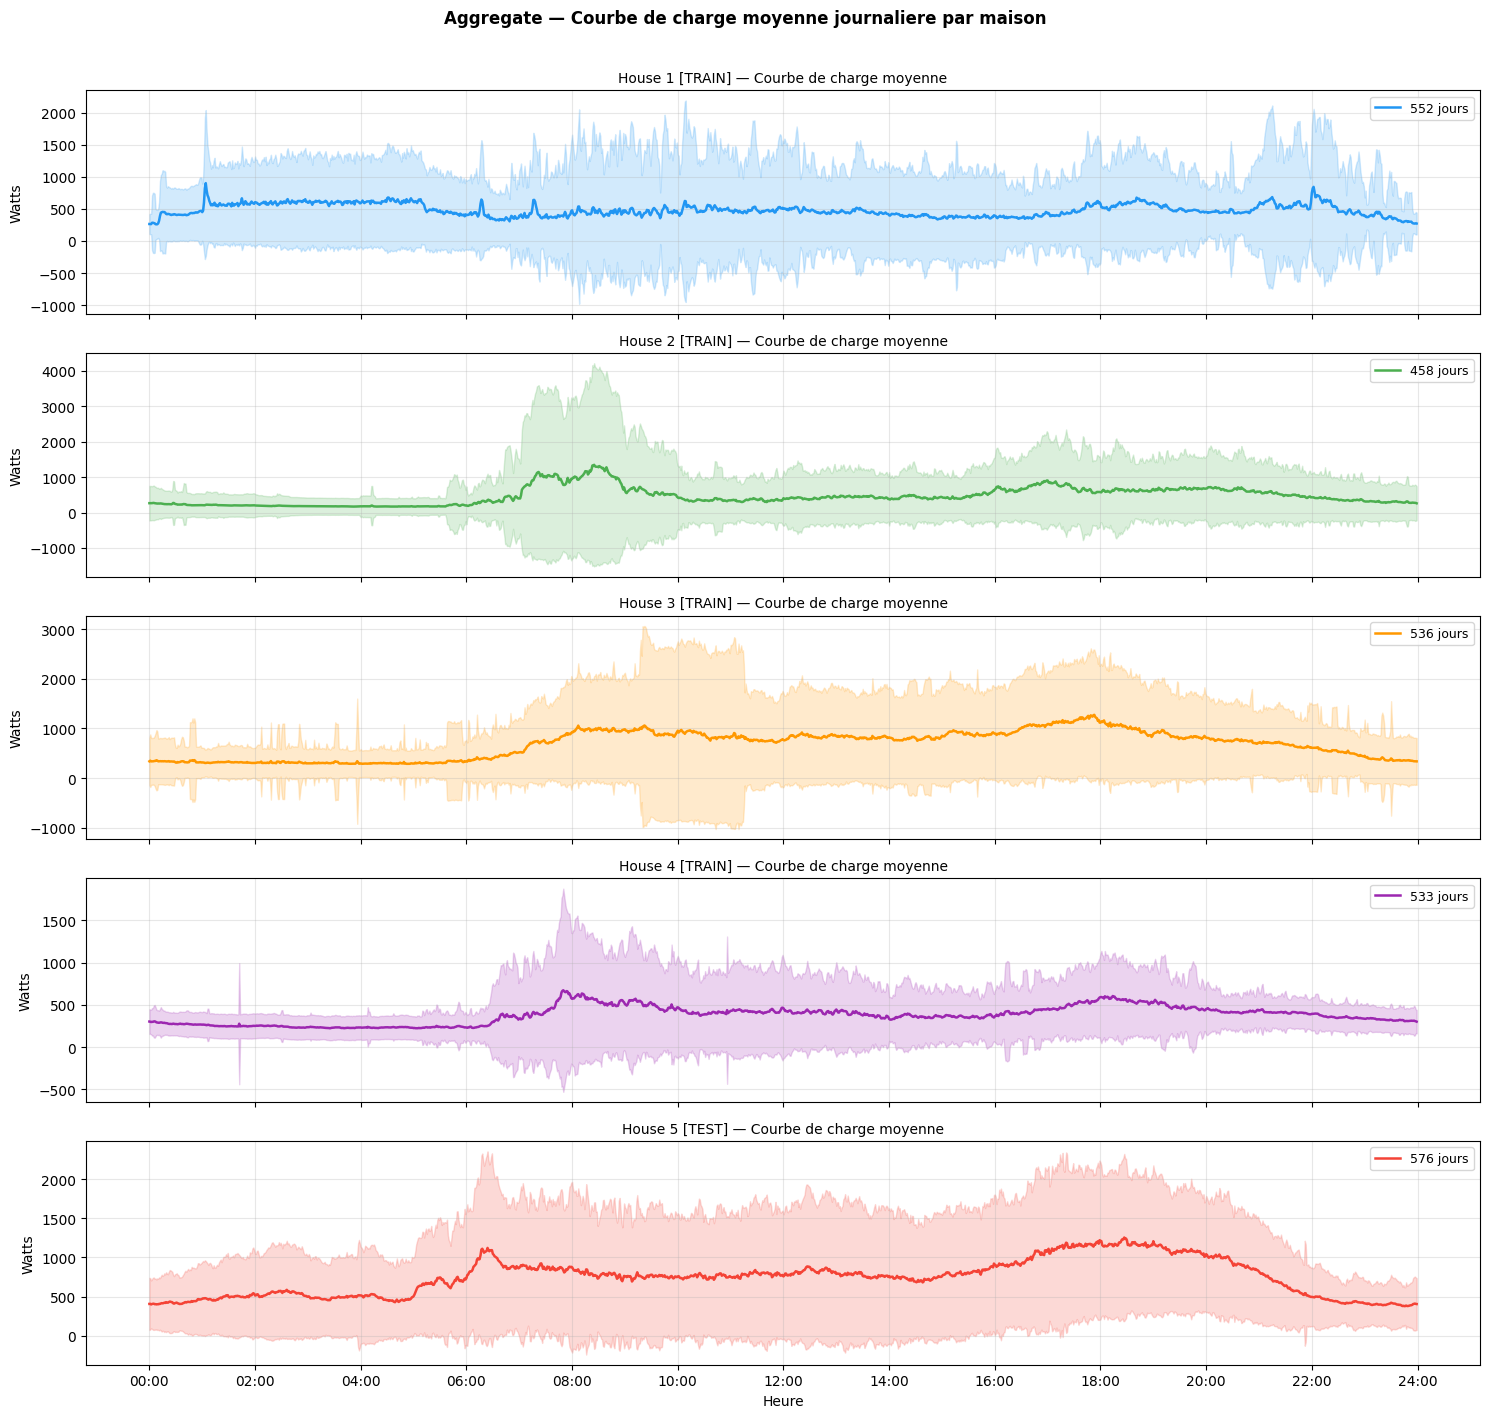

In [5]:
# Courbes de charge moyennes par maison
hours_axis = np.arange(1440) / 60
colors_h   = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

fig, axes = plt.subplots(5, 1, figsize=(15, 14), sharex=True)
for i, (hid, data) in enumerate(houses.items()):
    ax  = axes[i]
    X   = data['X']
    tag = 'TEST' if hid == CFG['test_house_idx'] else 'TRAIN'
    mu  = X.mean(axis=0)
    sd  = X.std(axis=0)
    ax.fill_between(hours_axis, mu - sd, mu + sd, alpha=0.2, color=colors_h[i])
    ax.plot(hours_axis, mu, color=colors_h[i], linewidth=1.8,
            label=f'{len(data["dates"])} jours')
    ax.set_title(f'House {hid+1} [{tag}] — Courbe de charge moyenne', fontsize=10)
    ax.set_ylabel('Watts')
    ax.set_xticks(range(0, 25, 2))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 25, 2)])
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Heure')
plt.suptitle('Aggregate — Courbe de charge moyenne journaliere par maison',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig('01_load_curves.png')
plt.show()

  Sauvegarde -> /content/drive/MyDrive/REFIT_dataset clean/outputs/02_heatmap.png


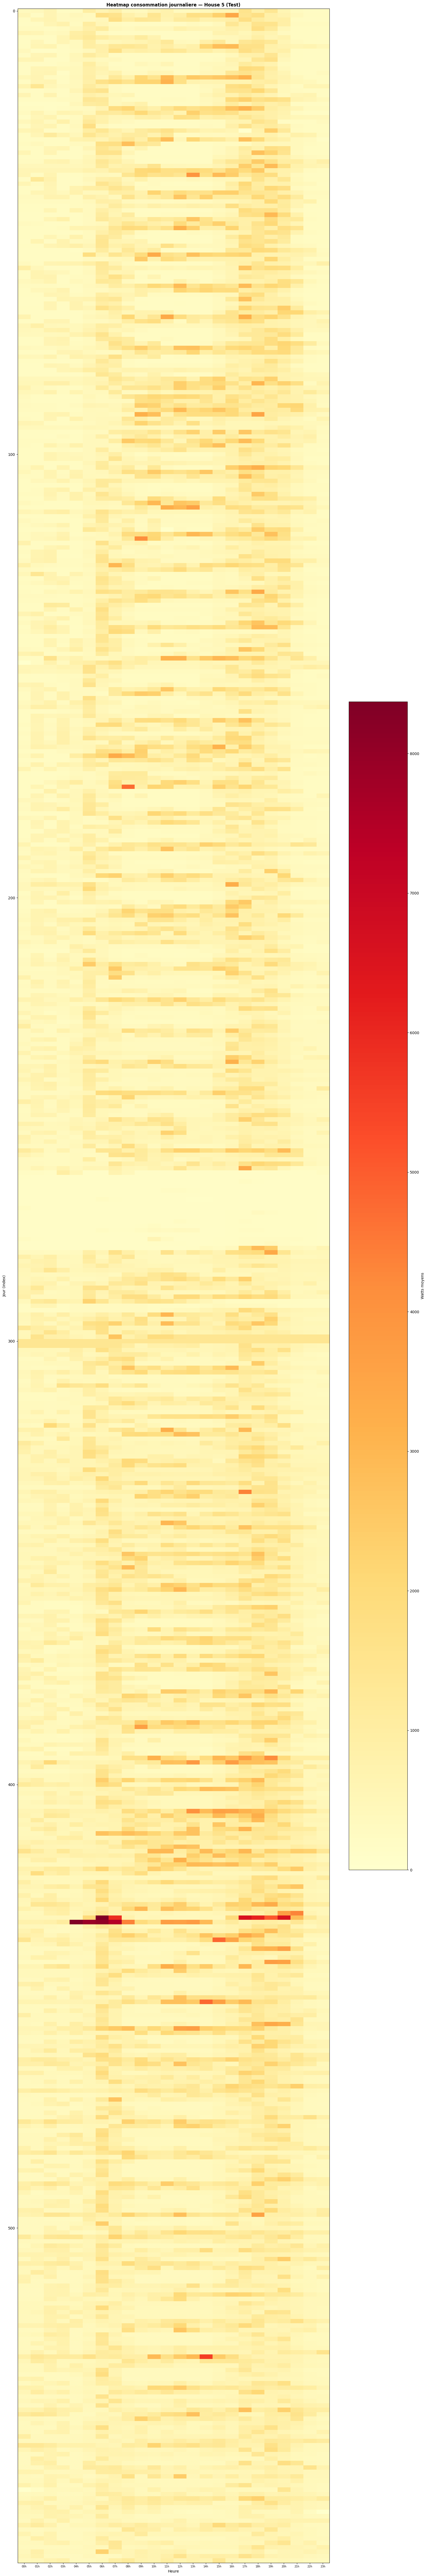

In [6]:
# Heatmap calendaire — maison de test
test_data  = houses[CFG['test_house_idx']]
X_test_raw = test_data['X']

# Moyenne horaire pour la heatmap (1440 -> 24)
hourly = X_test_raw.reshape(len(X_test_raw), 24, 60).mean(axis=2)

fig, ax = plt.subplots(figsize=(16, max(4, len(hourly) // 6)))
im = ax.imshow(hourly, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}h' for h in range(24)], fontsize=7)
ax.set_xlabel('Heure'); ax.set_ylabel('Jour (index)')
ax.set_title(f'Heatmap consommation journaliere — House {CFG["test_house_idx"]+1} (Test)',
             fontweight='bold')
plt.colorbar(im, ax=ax, label='Watts moyens')
plt.tight_layout()
save_fig('02_heatmap.png')
plt.show()

## 5. Prétraitement

In [7]:
# Donnees d'entrainement : tous les jours des 4 maisons TRAIN
train_ids   = [i for i in range(len(CFG['house_paths'])) if i != CFG['test_house_idx']]
X_train_all = np.concatenate([houses[i]['X'] for i in train_ids])

print(f'Maisons TRAIN   : {[i+1 for i in train_ids]}')
print(f'Jours TRAIN     : {len(X_train_all):,}  shape={X_train_all.shape}')

# MinMaxScaler ajuste sur TRAIN uniquement
scaler     = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train_all)

X_test_sc  = scaler.transform(houses[CFG['test_house_idx']]['X'])
print(f'\nMaison TEST     : House {CFG["test_house_idx"]+1}')
print(f'Jours TEST      : {len(X_test_sc):,}  shape={X_test_sc.shape}')

# Split train / val
X_tr, X_val = train_test_split(X_train_sc, test_size=CFG['val_split'],
                                random_state=SEED, shuffle=True)
print(f'\nTrain : {X_tr.shape}  |  Val : {X_val.shape}')

Maisons TRAIN   : [1, 2, 3, 4]
Jours TRAIN     : 2,079  shape=(2079, 1440)

Maison TEST     : House 5
Jours TEST      : 576  shape=(576, 1440)

Train : (1871, 1440)  |  Val : (208, 1440)


In [8]:
# DataLoaders — shape attendue par le LSTM : (batch, 1440, 1)
def make_loader(X, batch_size, shuffle=True):
    t  = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    ds = TensorDataset(t, t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      pin_memory=True, num_workers=2)

train_loader = make_loader(X_tr,  CFG['batch_size'], shuffle=True)
val_loader   = make_loader(X_val, CFG['batch_size'], shuffle=False)
print(f'Train batches : {len(train_loader)}  |  Val batches : {len(val_loader)}')

Train batches : 59  |  Val batches : 7


## 6. Architecture LSTM Autoencoder

In [9]:
class LSTMEncoder(nn.Module):
    """Sequence (1440, 1) -> vecteur latent (hidden_size,)"""
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return h_n[-1]   # (batch, hidden)


class LSTMDecoder(nn.Module):
    """Vecteur latent (hidden_size,) -> sequence reconstruite (1440, 1)"""
    def __init__(self, hidden_size, output_size, seq_len, num_layers, dropout):
        super().__init__()
        self.seq_len = seq_len
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, z):
        z_seq  = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.lstm(z_seq)
        return self.fc(out)   # (batch, 1440, 1)


class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, seq_len, num_layers, dropout):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden_size, num_layers, dropout)
        self.decoder = LSTMDecoder(hidden_size, input_size, seq_len, num_layers, dropout)
    def forward(self, x):
        return self.decoder(self.encoder(x))


model = LSTMAutoencoder(
    input_size  = 1,
    hidden_size = CFG['hidden_size'],
    seq_len     = CFG['minutes_per_day'],
    num_layers  = CFG['num_layers'],
    dropout     = CFG['dropout'],
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nParametres entrainables : {n_params:,}')

LSTMAutoencoder(
  (encoder): LSTMEncoder(
    (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.2)
  )
  (decoder): LSTMDecoder(
    (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.2)
    (fc): Linear(in_features=128, out_features=1, bias=True)
  )
)

Parametres entrainables : 463,489


## 7. Entraînement

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=CFG['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5)
criterion = nn.MSELoss()
def run_epoch(loader, train=True):
    model.train(train)
    total = 0.
    ctx   = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, _ in loader:
            xb   = xb.to(DEVICE, non_blocking=True)
            loss = criterion(model(xb), xb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total += loss.item() * len(xb)
    return total / len(loader.dataset)


train_losses, val_losses = [], []
best_val, best_state     = np.inf, None

pbar = tqdm(range(1, CFG['epochs'] + 1), desc='Entrainement')
for epoch in pbar:
    tr  = run_epoch(train_loader, train=True)
    val = run_epoch(val_loader,   train=False)
    scheduler.step(val)
    train_losses.append(tr)
    val_losses.append(val)
    if val < best_val:
        best_val   = val
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    pbar.set_postfix(train=f'{tr:.5f}', val=f'{val:.5f}', best=f'{best_val:.5f}')

model.load_state_dict(best_state)
print(f'\nMeilleure val MSE : {best_val:.6f}')

Entrainement:   0%|          | 0/50 [00:00<?, ?it/s]


Meilleure val MSE : 0.006611


  Sauvegarde -> /content/drive/MyDrive/REFIT_dataset clean/outputs/03_training_curve.png


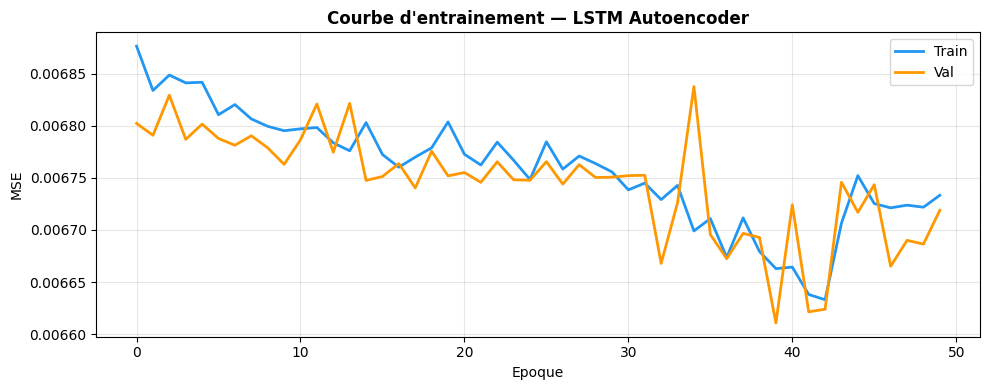

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train', color='#2196F3', linewidth=2)
ax.plot(val_losses,   label='Val',   color='#FF9800', linewidth=2)
ax.set_xlabel('Epoque'); ax.set_ylabel('MSE')
ax.set_title("Courbe d'entrainement — LSTM Autoencoder", fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
save_fig('03_training_curve.png')
plt.show()

## 8. Seuil d'anomalie

Erreurs TRAIN  moy=0.00664  std=0.00828  max=0.10406
Seuil @ 95e percentile : 0.02176
  Sauvegarde -> /content/drive/MyDrive/REFIT_dataset clean/outputs/04_error_distribution.png


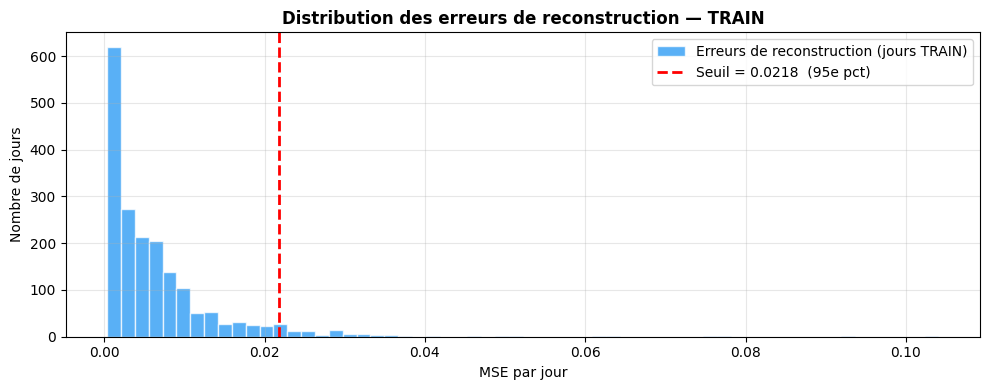

In [14]:
def get_errors(X_sc, batch_size=64):
    """Erreur MSE de reconstruction par jour. Shape retournee : (n_jours,)"""
    model.eval()
    errors = []
    with torch.no_grad():
        for s in range(0, len(X_sc), batch_size):
            xb  = torch.tensor(X_sc[s:s+batch_size]).unsqueeze(-1).to(DEVICE, non_blocking=True)
            err = ((xb - model(xb)) ** 2).mean(dim=(1, 2)).cpu().numpy()
            errors.extend(err)
    return np.array(errors)


train_errors = get_errors(X_tr)
threshold    = np.percentile(train_errors, CFG['threshold_percentile'])

print(f'Erreurs TRAIN  moy={train_errors.mean():.5f}  std={train_errors.std():.5f}  max={train_errors.max():.5f}')
print(f'Seuil @ {CFG["threshold_percentile"]}e percentile : {threshold:.5f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_errors, bins=60, color='#2196F3', alpha=0.75, edgecolor='white',
        label='Erreurs de reconstruction (jours TRAIN)')
ax.axvline(threshold, color='red', linewidth=2, linestyle='--',
           label=f'Seuil = {threshold:.4f}  ({CFG["threshold_percentile"]}e pct)')
ax.set_xlabel('MSE par jour'); ax.set_ylabel('Nombre de jours')
ax.set_title('Distribution des erreurs de reconstruction — TRAIN', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
save_fig('04_error_distribution.png')
plt.show()

## 9. Détection d'anomalies — Maison de test

In [15]:
test_errors = get_errors(X_test_sc)
y_pred      = (test_errors > threshold).astype(int)

n_anom  = y_pred.sum()
n_total = len(y_pred)
print(f'House {CFG["test_house_idx"]+1} (Test)')
print(f'  Jours analyses  : {n_total}')
print(f'  Jours anormaux  : {n_anom}  ({n_anom/n_total*100:.1f}%)')
print(f'  Jours normaux   : {n_total - n_anom}  ({(n_total-n_anom)/n_total*100:.1f}%)')
print(f'  Seuil utilise   : {threshold:.5f}')

House 5 (Test)
  Jours analyses  : 576
  Jours anormaux  : 13  (2.3%)
  Jours normaux   : 563  (97.7%)
  Seuil utilise   : 0.02176


## 10. Visualisations

  Sauvegarde -> /content/drive/MyDrive/REFIT_dataset clean/outputs/05_anomaly_timeline.png


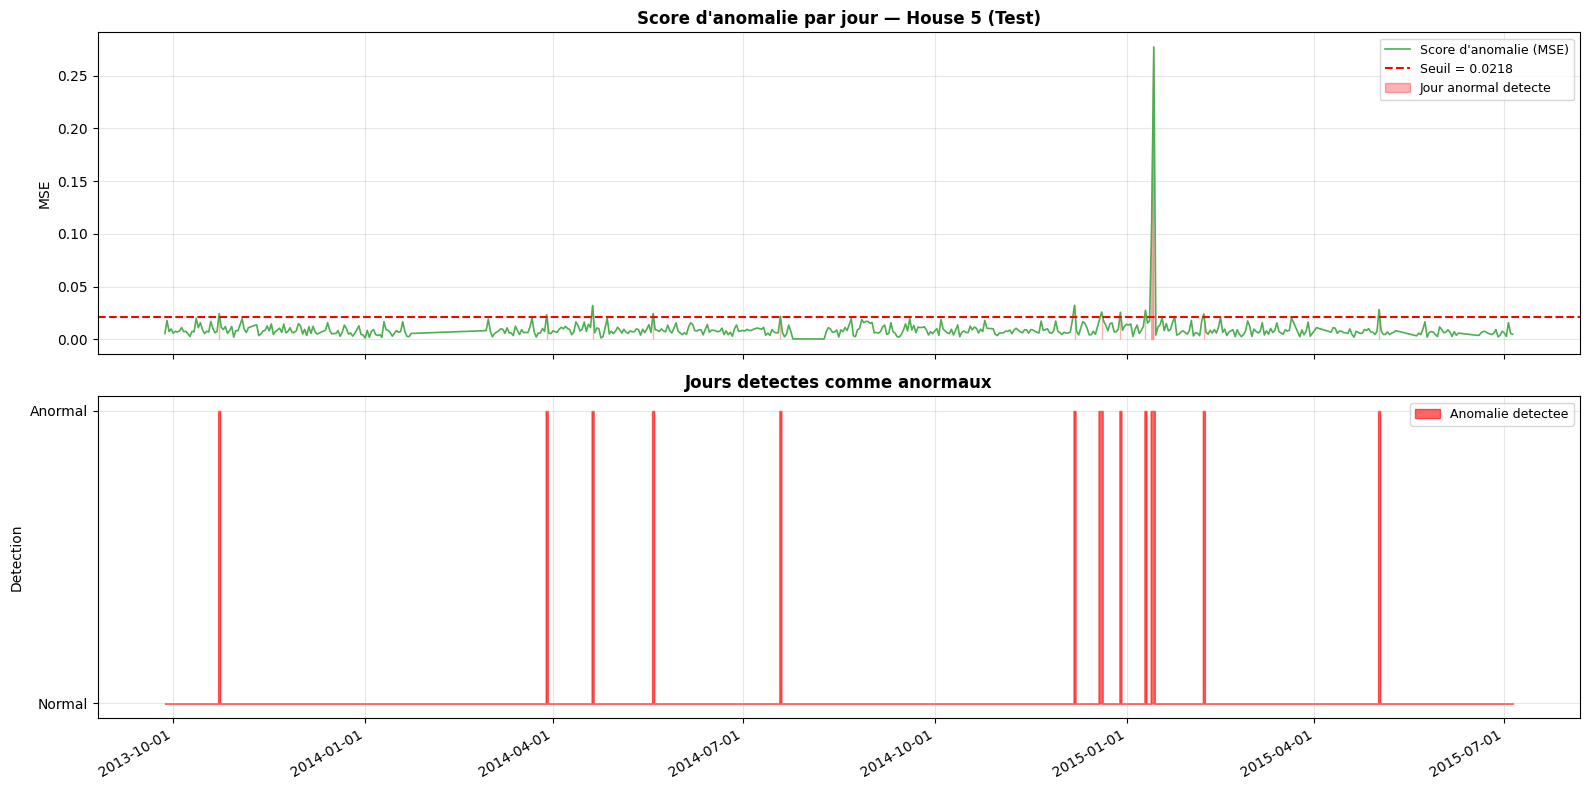

In [16]:
# Timeline : score d'anomalie par jour
dates_test = pd.to_datetime(test_data['dates'][:len(test_errors)])

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(dates_test, test_errors, color='#4CAF50', linewidth=1.2,
             label="Score d'anomalie (MSE)")
axes[0].axhline(threshold, color='red', linewidth=1.5, linestyle='--',
                label=f'Seuil = {threshold:.4f}')
axes[0].fill_between(dates_test, 0, test_errors,
                     where=test_errors > threshold,
                     color='red', alpha=0.3, label='Jour anormal detecte')
axes[0].set_ylabel('MSE')
axes[0].set_title(f"Score d'anomalie par jour — House {CFG['test_house_idx']+1} (Test)",
                  fontweight='bold')
axes[0].legend(loc='upper right', fontsize=9); axes[0].grid(alpha=0.3)

axes[1].fill_between(dates_test, 0, y_pred,
                     step='mid', color='red', alpha=0.6, label='Anomalie detectee')
axes[1].set_ylabel('Detection'); axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Normal', 'Anormal'])
axes[1].set_title('Jours detectes comme anormaux', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9); axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
save_fig('05_anomaly_timeline.png')
plt.show()

  Sauvegarde -> /content/drive/MyDrive/REFIT_dataset clean/outputs/06_reconstruction.png


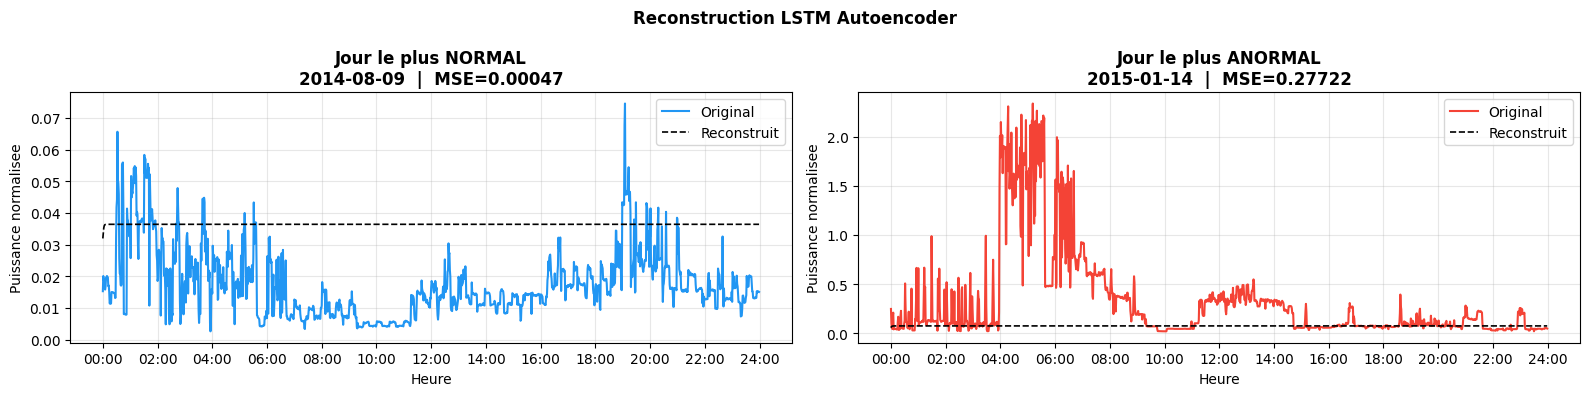

In [17]:
# Reconstruction : jour normal vs jour le plus anormal
worst_idx = int(np.argmax(test_errors))
best_idx  = int(np.argmin(test_errors))

model.eval()
with torch.no_grad():
    def reconstruct(idx):
        x = torch.tensor(X_test_sc[idx]).unsqueeze(0).unsqueeze(-1).to(DEVICE)
        return model(x).squeeze().cpu().numpy()
    recon_best  = reconstruct(best_idx)
    recon_worst = reconstruct(worst_idx)

h = np.arange(1440) / 60
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, idx, recon, title, color in [
    (axes[0], best_idx,  recon_best,  'Jour le plus NORMAL',  '#2196F3'),
    (axes[1], worst_idx, recon_worst, 'Jour le plus ANORMAL', '#F44336'),
]:
    ax.plot(h, X_test_sc[idx], color=color, linewidth=1.5, label='Original')
    ax.plot(h, recon, color='black', linewidth=1.2, linestyle='--', label='Reconstruit')
    ax.set_title(f'{title}\n{test_data["dates"][idx]}  |  MSE={test_errors[idx]:.5f}',
                 fontweight='bold')
    ax.set_xlabel('Heure'); ax.set_ylabel('Puissance normalisee')
    ax.set_xticks(range(0, 25, 2))
    ax.set_xticklabels([f'{h_:02d}:00' for h_ in range(0, 25, 2)])
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Reconstruction LSTM Autoencoder', fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('06_reconstruction.png')
plt.show()

  Sauvegarde -> /content/drive/MyDrive/REFIT_dataset clean/outputs/07_top10_anomalies.png


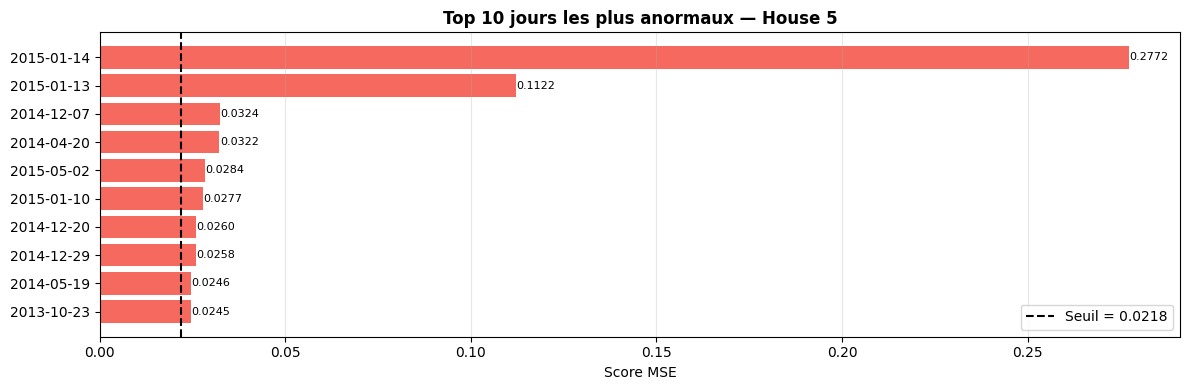

In [18]:
# Top 10 jours les plus anormaux
top10_idx    = np.argsort(test_errors)[::-1][:10]
top10_dates  = [test_data['dates'][i] for i in top10_idx]
top10_scores = test_errors[top10_idx]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.barh(range(10), top10_scores[::-1], color='#F44336', alpha=0.8)
ax.set_yticks(range(10))
ax.set_yticklabels(top10_dates[::-1])
ax.axvline(threshold, color='black', linewidth=1.5, linestyle='--',
           label=f'Seuil = {threshold:.4f}')
ax.set_xlabel('Score MSE')
ax.set_title(f'Top 10 jours les plus anormaux — House {CFG["test_house_idx"]+1}',
             fontweight='bold')
ax.legend(); ax.grid(axis='x', alpha=0.3)
for bar, score in zip(bars[::-1], top10_scores):
    ax.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=8)
plt.tight_layout()
save_fig('07_top10_anomalies.png')
plt.show()

  Sauvegarde -> /content/drive/MyDrive/REFIT_dataset clean/outputs/08_hour_error_heatmap.png


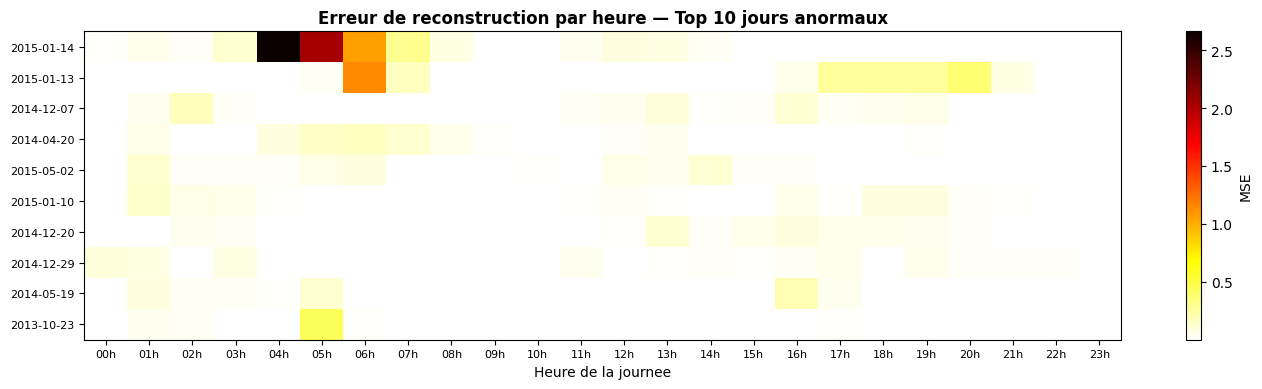

In [19]:
# Heatmap erreur par heure — Top 10 jours anormaux
model.eval()
minute_errors = []
with torch.no_grad():
    for idx in top10_idx:
        xb  = torch.tensor(X_test_sc[idx]).unsqueeze(0).unsqueeze(-1).to(DEVICE)
        rec = model(xb).squeeze().cpu().numpy()
        minute_errors.append((X_test_sc[idx] - rec) ** 2)

me_hourly = np.array(minute_errors).reshape(10, 24, 60).mean(axis=2)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(me_hourly, aspect='auto', cmap='hot_r', interpolation='nearest')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h_:02d}h' for h_ in range(24)], fontsize=8)
ax.set_yticks(range(10))
ax.set_yticklabels(top10_dates, fontsize=8)
ax.set_xlabel('Heure de la journee')
ax.set_title('Erreur de reconstruction par heure — Top 10 jours anormaux',
             fontweight='bold')
plt.colorbar(im, ax=ax, label='MSE')
plt.tight_layout()
save_fig('08_hour_error_heatmap.png')
plt.show()

  Sauvegarde -> /content/drive/MyDrive/REFIT_dataset clean/outputs/09_threshold_sensitivity.png


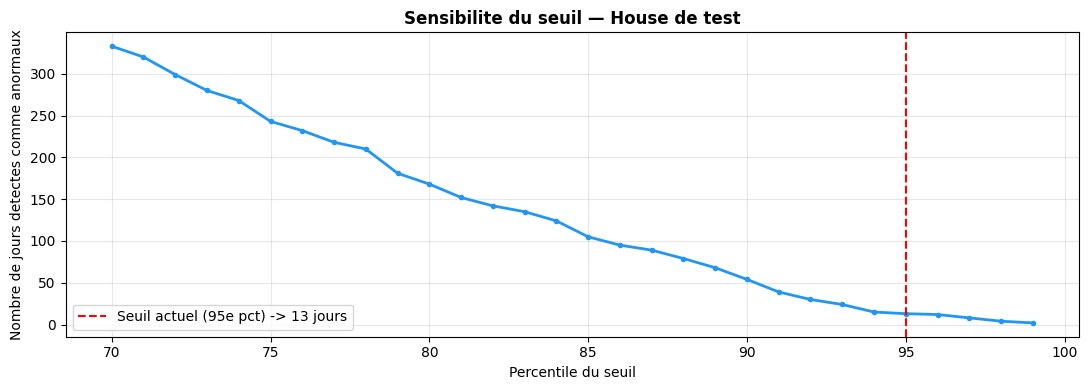

In [20]:
# Sensibilite du seuil
percentiles = range(70, 100)
n_detected  = [(test_errors > np.percentile(train_errors, p)).sum() for p in percentiles]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(percentiles, n_detected, color='#2196F3', linewidth=2, marker='o', markersize=3)
ax.axvline(CFG['threshold_percentile'], color='red', linestyle='--',
           label=f"Seuil actuel ({CFG['threshold_percentile']}e pct) -> {n_detected[CFG['threshold_percentile']-70]} jours")
ax.set_xlabel('Percentile du seuil')
ax.set_ylabel('Nombre de jours detectes comme anormaux')
ax.set_title('Sensibilite du seuil — House de test', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
save_fig('09_threshold_sensitivity.png')
plt.show()

## 11. Leave-One-Out sur les 5 maisons

In [21]:
# Mettre FULL_LOO = False pour garder uniquement le resultat ci-dessus
FULL_LOO = True


def loo_pipeline(test_idx, houses, cfg, seed=SEED):
    np.random.seed(seed); torch.manual_seed(seed)
    tr_ids   = [i for i in range(len(cfg['house_paths'])) if i != test_idx]
    X_tr_all = np.concatenate([houses[i]['X'] for i in tr_ids])
    sc       = MinMaxScaler()
    X_tr_sc  = sc.fit_transform(X_tr_all)
    X_tr_s, X_v_s = train_test_split(X_tr_sc, test_size=cfg['val_split'],
                                      random_state=seed, shuffle=True)
    tl = make_loader(X_tr_s, cfg['batch_size'], shuffle=True)
    vl = make_loader(X_v_s,  cfg['batch_size'], shuffle=False)

    m    = LSTMAutoencoder(1, cfg['hidden_size'], cfg['minutes_per_day'],
                            cfg['num_layers'], cfg['dropout']).to(DEVICE)
    opt  = torch.optim.Adam(m.parameters(), lr=cfg['lr'])
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.5, patience=5)
    crit = nn.MSELoss()
    best_v, best_s = np.inf, None

    for _ in tqdm(range(cfg['epochs']), desc=f'LOO House {test_idx+1}', leave=False):
        m.train()
        for xb, _ in tl:
            xb = xb.to(DEVICE, non_blocking=True)
            l  = crit(m(xb), xb)
            opt.zero_grad(); l.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
        m.eval(); vl_ = 0
        with torch.no_grad():
            for xb, _ in vl:
                xb = xb.to(DEVICE, non_blocking=True)
                vl_ += crit(m(xb), xb).item() * len(xb)
        vl_ /= len(vl.dataset); sch.step(vl_)
        if vl_ < best_v:
            best_v = vl_
            best_s = {k: v.cpu().clone() for k, v in m.state_dict().items()}

    m.load_state_dict(best_s); m.eval()

    def errs(X_sc):
        e = []
        with torch.no_grad():
            for s in range(0, len(X_sc), 64):
                xb = torch.tensor(X_sc[s:s+64]).unsqueeze(-1).to(DEVICE, non_blocking=True)
                e.extend(((xb - m(xb))**2).mean(dim=(1,2)).cpu().numpy())
        return np.array(e)

    thr    = np.percentile(errs(X_tr_s), cfg['threshold_percentile'])
    X_te   = sc.transform(houses[test_idx]['X'])
    te_err = errs(X_te)
    n_det  = (te_err > thr).sum()

    return dict(
        Maison         = f'House {test_idx+1}',
        Jours_test     = len(te_err),
        Jours_anormaux = int(n_det),
        Pct_anormaux   = round(n_det / len(te_err) * 100, 1),
        Seuil          = round(float(thr), 5),
        MSE_moy        = round(float(te_err.mean()), 5),
        MSE_max        = round(float(te_err.max()), 5),
    )


if FULL_LOO:
    loo_results = []
    for idx in range(len(CFG['house_paths'])):
        r = loo_pipeline(idx, houses, CFG)
        loo_results.append(r)
        print(f"House {idx+1} -> {r['Jours_anormaux']}/{r['Jours_test']} jours anormaux "
              f"({r['Pct_anormaux']}%)  MSE moy={r['MSE_moy']}")
else:
    loo_results = [dict(
        Maison='House ' + str(CFG['test_house_idx']+1),
        Jours_test=len(test_errors),
        Jours_anormaux=int(y_pred.sum()),
        Pct_anormaux=round(float(y_pred.mean())*100, 1),
        Seuil=round(float(threshold), 5),
        MSE_moy=round(float(test_errors.mean()), 5),
        MSE_max=round(float(test_errors.max()), 5),
    )]

results_df = pd.DataFrame(loo_results).set_index('Maison')
display(results_df)

LOO House 1:   0%|          | 0/50 [00:00<?, ?it/s]

House 1 -> 103/552 jours anormaux (18.7%)  MSE moy=0.0122


LOO House 2:   0%|          | 0/50 [00:00<?, ?it/s]

House 2 -> 37/458 jours anormaux (8.1%)  MSE moy=0.00985


LOO House 3:   0%|          | 0/50 [00:00<?, ?it/s]

...

LOO House 4:   0%|          | 0/50 [00:00<?, ?it/s]

House 4 -> 0/533 jours anormaux (0.0%)  MSE moy=0.00154


LOO House 5:   0%|          | 0/50 [00:00<?, ?it/s]

House 5 -> 12/576 jours anormaux (2.1%)  MSE moy=0.00919


,Jours_test,Jours_anormaux,Pct_anormaux,Seuil,MSE_moy,MSE_max
Maison,,,,,,
House 1,552,103,18.7,0.02156,0.01220,0.30048
House 2,458,37,8.1,0.01792,0.00985,0.06120
House 3,536,35,6.5,0.02118,0.00976,0.71746
House 4,533,0,0.0,0.01847,0.00154,0.01699
House 5,576,12,2.1,0.02207,0.00919,0.27841


  Sauvegarde -> /content/drive/MyDrive/REFIT_dataset clean/outputs/10_loo_results.png


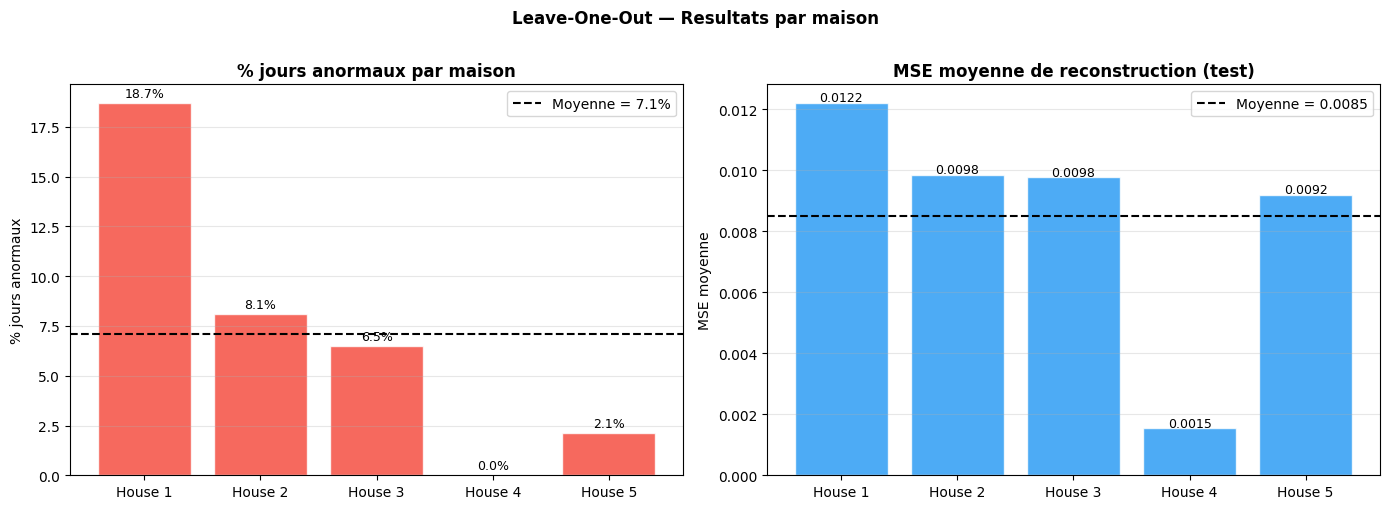

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = results_df.index.tolist()

vals = results_df['Pct_anormaux'].values
axes[0].bar(labels, vals, color='#F44336', alpha=0.8, edgecolor='white')
axes[0].axhline(vals.mean(), color='black', linestyle='--',
                label=f'Moyenne = {vals.mean():.1f}%')
for i, v in enumerate(vals):
    axes[0].text(i, v + 0.3, f'{v}%', ha='center', fontsize=9)
axes[0].set_ylabel('% jours anormaux')
axes[0].set_title('% jours anormaux par maison', fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

vals2 = results_df['MSE_moy'].values
axes[1].bar(labels, vals2, color='#2196F3', alpha=0.8, edgecolor='white')
axes[1].axhline(vals2.mean(), color='black', linestyle='--',
                label=f'Moyenne = {vals2.mean():.4f}')
for i, v in enumerate(vals2):
    axes[1].text(i, v + 0.00005, f'{v:.4f}', ha='center', fontsize=9)
axes[1].set_ylabel('MSE moyenne')
axes[1].set_title('MSE moyenne de reconstruction (test)', fontweight='bold')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Leave-One-Out — Resultats par maison', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig('10_loo_results.png')
plt.show()

## 12. Sauvegarde

In [23]:
torch.save({
    'model_state'   : model.state_dict(),
    'config'        : CFG,
    'threshold'     : float(threshold),
    'scaler_scale_' : scaler.scale_.tolist(),
    'scaler_min_'   : scaler.min_.tolist(),
}, f"{CFG['output_dir']}/lstm_ae.pt")

results_df.reset_index().to_csv(f"{CFG['output_dir']}/loo_results.csv", index=False)

print(f"Modele    -> {CFG['output_dir']}/lstm_ae.pt")
print(f"Resultats -> {CFG['output_dir']}/loo_results.csv")
print(f"Graphiques -> {CFG['output_dir']}/01_*.png ... 10_*.png")

Modele    -> /content/drive/MyDrive/REFIT_dataset clean/outputs/lstm_ae.pt
Resultats -> /content/drive/MyDrive/REFIT_dataset clean/outputs/loo_results.csv
Graphiques -> /content/drive/MyDrive/REFIT_dataset clean/outputs/01_*.png ... 10_*.png


---
## Résumé

| Etape | Detail |
|---|---|
| **Features** | Aggregate uniquement — Issues et Appliances ignores |
| **Conversion** | 15 sec -> 1 min -> 1 ligne/jour x 1440 colonnes |
| **Mode** | Non supervise pur — pas de labels |
| **Modele** | LSTM Autoencoder (seq=1440, hidden=128, layers=2) |
| **Score** | MSE entre courbe originale et courbe reconstruite |
| **Seuil** | 95e percentile des erreurs TRAIN (ajustable dans CFG) |
| **Eval** | Leave-One-Out : % jours anormaux + MSE par maison |

### Prochaines etapes
1. **TCN Autoencoder** — plus rapide sur seq_len=1440
2. **Transformer Autoencoder** — attention sur les patterns intra-journaliers
3. **VAE** — score d'anomalie probabiliste